# Étape 1 — Réduction de dimension & Clustering

**Projet SY09 — Décrochage scolaire en mathématiques**  
Notebook 2/3 · Distance mixte (§2.2) · AFTD (Ch. 6) · CAH-Ward + K-means (Ch. 7) · Comparaison ARI

---

## Contexte

Ce notebook constitue l'**étape 1** du projet (analyse non supervisée). Le notebook 1 a mis
en évidence un décrochage spécifique aux mathématiques (9,6 % des élèves, défini par G3=0
et G1>0) et a identifié les variables les plus discriminantes via des tests Mann-Whitney et χ²
— en retenant un seuil α = 0,10 justifié par le faible effectif des décrocheurs (n = 38).
On cherche maintenant à faire émerger des **profils types d'élèves** à partir de ces seules
variables socio-comportementales, sans utiliser les notes trimestrielles.

Les variables retenues sont :
- **Numériques** : `failures`, `Medu`, `age` (p < 0,05, r > 0,15)
- **Catégorielles** : `higher`, `paid`, `romantic` (p < 0,05, V > 0,10)
- **Tendance conservée** : `Walc`, `schoolsup` (p < 0,10, effect size non négligeable)

**Plan :**
1. Imports et chargement
2. Sélection de variables — rappel et justification
3. Distance mixte (cours §2.2)
4. AFTD — double-centrage, scree plot, Shepard (cours Ch. 6)
5. CAH-Ward — dendrogramme, sauts d'inertie, choix de K (cours Ch. 7 §5.5)
6. K-means — coude sur $I_W$ (cours Ch. 7 §6.1)
7. Comparaison ARI (cours §7)
8. Caractérisation descriptive des profils
9. Synthèse et articulation vers le notebook 3

---
## 1. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform, cdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
BLEU   = '#2196F3'
ROUGE  = '#E53935'
VERT   = '#43A047'
ORANGE = '#FB8C00'
PAL    = [BLEU, ROUGE, VERT, ORANGE]

In [2]:
mat = pd.read_csv('Data/student-mat.csv', sep=',')

# Variable cible définie en notebook 1 : G3=0 ET G1>0
mat['decrocheur'] = ((mat['G3'] == 0) & (mat['G1'] > 0)).astype(int)

print(f"Dataset maths    : {mat.shape[0]} élèves × {mat.shape[1]} variables")
print(f"Décrocheurs      : {mat['decrocheur'].sum()} ({100*mat['decrocheur'].mean():.1f} %)")

Dataset maths    : 395 élèves × 34 variables
Décrocheurs      : 38 (9.6 %)


## 2. Sélection des variables

Les tests Mann-Whitney et χ² réalisés en notebook 0 (cf. `00_analyse_preliminaire.ipynb`)
ont identifié 8 variables à pouvoir discriminant vis-à-vis du décrochage, en retenant
α = 0,10 — seuil justifié par le faible effectif des décrocheurs (n = 38) qui limite la
puissance des tests.

`absences` est écartée malgré sa p-valeur < 0,001. Les décrocheurs affichent
paradoxalement 0,00 absence en moyenne contre 6,32 pour les non-décrocheurs —
un résultat contre-intuitif dont l'interprétation est ambiguë : arrêt de la
comptabilisation après abandon administratif, problème de saisie, ou comportement
réel. Faute de pouvoir interpréter ce signal de façon fiable, la variable est
exclue plutôt que de construire un raisonnement sur une base incertaine.

Les 8 variables retenues sont :

| Variable | Type | p-valeur |
|----------|------|----------|
| `failures` | Numérique | < 0,001 |
| `Medu` | Numérique | 0,008 |
| `age` | Numérique | 0,039 |
| `Walc` | Numérique | 0,060 |
| `paid` | Catégorielle | 0,002 |
| `higher` | Catégorielle | 0,005 |
| `romantic` | Catégorielle | 0,014 |
| `schoolsup` | Catégorielle | 0,083 |

## 3. Distance mixte — cadre théorique du cours (§2.2)

Le cours SY09 (Ch. 2, §2.2) définit des distances adaptées à chaque type de variable.
Nos 8 variables retenues sont de deux natures :

**Variables ordinales** (`failures`, `Medu`, `age`, `Walc`) — distance sur rang renormalisé :
$$d_k(i,j) = \frac{|x_{ik} - x_{jk}|}{\max_k - \min_k}$$

**Variables binaires** (`higher`, `paid`, `romantic`, `schoolsup`) — désaccord simple :
$$d_k(i,j) = 1 - \mathbf{1}[x_{ik} = x_{jk}]$$

**Distance globale** (Gower 1971 — extension du cadre §2.2) :
$$d(i,j) = \frac{1}{8} \sum_{k=1}^{8} d_k(i,j) \in [0,1]$$

> **Remarque :** le cours (Ch. 6, §5.2) précise que si $\Delta$ n'est pas euclidienne,
> la matrice $W = -\frac{1}{2} Q_n \Delta^2 Q_n$ peut présenter des valeurs propres
> négatives. Ce cas est **attendu** pour les distances mixtes et sera vérifié en section 4.

In [3]:
VARS_NUM = ['failures', 'Medu', 'age', 'Walc']
VARS_CAT = ['higher', 'paid', 'schoolsup', 'romantic']

# Encodage binaire yes/no → 1/0
df_bin = mat[VARS_CAT].apply(lambda col: (col == 'yes').astype(float))
df_num = mat[VARS_NUM].copy()

n = len(mat)
D = np.zeros((n, n))

# Bloc numérique : |xi−xj| / range  (cours §2.2 — variable ordinale)
for col in VARS_NUM:
    v = df_num[col].values.astype(float)
    r = v.max() - v.min()
    if r > 0:
        D += np.abs(v[:,None] - v[None,:]) / r

# Bloc binaire : désaccord simple  (cours §2.2 — variable binaire)
for col in VARS_CAT:
    v = df_bin[col].values
    D += (v[:,None] != v[None,:]).astype(float)

D /= (len(VARS_NUM) + len(VARS_CAT))   # normalisation → D ∈ [0,1]
np.fill_diagonal(D, 0)

print("=== Propriétés de la matrice Δ ===")
print(f"Dimension          : {D.shape}")
print(f"Min / Max          : {D.min():.4f} / {D.max():.4f}")
print(f"Diagonale nulle    : {np.allclose(np.diag(D), 0)}")
print(f"Symétrique         : {np.allclose(D, D.T)}")

# Vérification euclidianité (cours §5.2)
Qn     = np.eye(n) - np.ones((n,n))/n
W_test = -0.5 * Qn @ (D**2) @ Qn
ev_test = np.linalg.eigvalsh(W_test)
n_neg   = (ev_test < -1e-8).sum()
print(f"Val. propres négatives : {n_neg}/{n}  (min = {ev_test[ev_test<0].min():.4f})")
print("→ Distance non euclidienne — comportement attendu pour données mixtes (cours §5.2)")

=== Propriétés de la matrice Δ ===
Dimension          : (395, 395)
Min / Max          : 0.0000 / 0.9062
Diagonale nulle    : True
Symétrique         : True
Val. propres négatives : 129/395  (min = -1.5386)
→ Distance non euclidienne — comportement attendu pour données mixtes (cours §5.2)


## 4. AFTD — Analyse Factorielle d'un Tableau de Distances

### 4.1 Rappel théorique (cours Ch. 6)

L'AFTD cherche une représentation $X$ dans $\mathbb{R}^p$ reproduisant au mieux la
dissimilarité initiale $\Delta$.

**1. Double-centrage :**
$$W = -\tfrac{1}{2} Q_n \Delta^2 Q_n \quad \text{où} \quad Q_n = I_n - \tfrac{1}{n}\mathbf{1}\mathbf{1}^T$$

**2. Décomposition spectrale de W :**
$$\mathbf{c}_\alpha = \sqrt{\lambda_\alpha} \cdot \mathbf{u}_\alpha$$

La distance mixte construite en section 3 n'étant pas euclidienne, $W$ présente des
valeurs propres négatives — comportement attendu et vérifié. On ne conserve donc que
les valeurs propres **positives** pour calculer les coordonnées factorielles, et le
pourcentage d'inertie expliqué est calculé sur leur **somme uniquement** (cours §5.2).

Le nombre de dimensions retenues se choisit par la **méthode du coude** (§6.1) et se
vérifie avec le **diagramme de Shepard** (§6.2).

In [4]:
# Double-centrage  W = -1/2 * Qn * Δ² * Qn  (cours Ch. 6)
Qn = np.eye(n) - np.ones((n,n))/n
W  = -0.5 * Qn @ (D**2) @ Qn

# Décomposition spectrale
eigvals_all, eigvecs_all = np.linalg.eigh(W)
idx     = np.argsort(eigvals_all)[::-1]
eigvals = eigvals_all[idx]
eigvecs = eigvecs_all[:, idx]

# Coordonnées factorielles — valeurs propres positives seulement (cours §5.2)
pos = eigvals > 1e-8
lam = eigvals[pos]
U   = eigvecs[:, pos]
C   = U * np.sqrt(lam)[None,:]          # (n × r) — c_α = √λ_α · u_α

inertie_totale = lam.sum()              # somme des VP positives uniquement
pct = 100 * lam / inertie_totale

print("Valeurs propres et inerties expliquées (VP positives uniquement)")
print(f"{'Axe':>4} {'λ':>10} {'Inertie %':>11} {'Cumulée %':>11}")
print("-" * 42)
cumul = 0
n_show = min(12, pos.sum())
for i in range(n_show):
    cumul += pct[i]
    print(f"{i+1:>4} {lam[i]:>10.4f} {pct[i]:>10.2f}% {cumul:>10.2f}%")

print(f"\nVal. propres positives : {pos.sum()}")
print(f"Val. propres négatives : {(~pos).sum()}  (min = {eigvals[~pos].min():.4f})")

Valeurs propres et inerties expliquées (VP positives uniquement)
 Axe          λ   Inertie %   Cumulée %
------------------------------------------
   1     8.1119      24.11%      24.11%
   2     6.9812      20.75%      44.85%
   3     4.4665      13.27%      58.12%
   4     3.1603       9.39%      67.52%
   5     2.9371       8.73%      76.24%
   6     1.7954       5.34%      81.58%
   7     1.3732       4.08%      85.66%
   8     1.0535       3.13%      88.79%
   9     0.7327       2.18%      90.97%
  10     0.6729       2.00%      92.97%
  11     0.4655       1.38%      94.35%
  12     0.4515       1.34%      95.69%

Val. propres positives : 20
Val. propres négatives : 375  (min = -1.5386)


### 4.2 Choix du nombre d'axes — méthode du coude et diagramme de Shepard

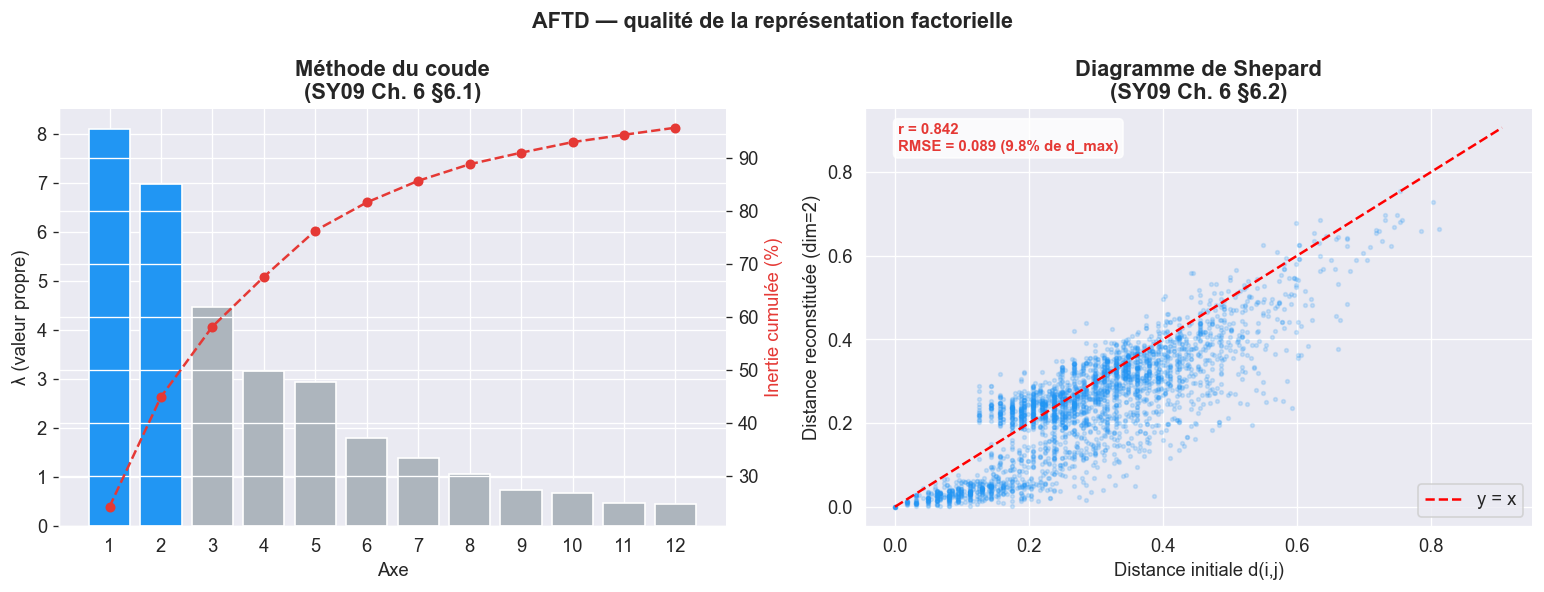

→ Axes retenus : 2  |  Inertie cumulée : 44.9%
  Shepard r = 0.842  |  RMSE = 0.089 (9.8% de d_max)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Scree plot (méthode du coude, cours §6.1) ──
ax = axes[0]
k_show = min(12, pos.sum())
bars_color = [BLEU if i < 2 else '#adb5bd' for i in range(k_show)]
ax.bar(range(1, k_show+1), lam[:k_show], color=bars_color, edgecolor='white')
ax2_tw = ax.twinx()
cumul_pct = np.cumsum(pct[:k_show])
ax2_tw.plot(range(1, k_show+1), cumul_pct, 'o--', color=ROUGE, ms=5, lw=1.5)
ax2_tw.set_ylabel('Inertie cumulée (%)', color=ROUGE)
ax.set_xlabel('Axe')
ax.set_ylabel('λ (valeur propre)')
ax.set_title('Méthode du coude\n(SY09 Ch. 6 §6.1)', fontweight='bold')
ax.set_xticks(range(1, k_show+1))

# ── Diagramme de Shepard (cours §6.2) ──
C2 = C[:, :2]    # représentation 2D — à ajuster après lecture du scree plot
ax2 = axes[1]
idx_tri = np.triu_indices(n, k=1)
d_init  = D[idx_tri]
D_rec   = cdist(C2, C2)
d_rec   = D_rec[idx_tri]
rng = np.random.default_rng(42)
spl = rng.choice(len(d_init), 3000, replace=False)
ax2.scatter(d_init[spl], d_rec[spl], alpha=0.18, s=5, color=BLEU)
ax2.plot([0, d_init.max()], [0, d_init.max()], 'r--', lw=1.5, label='y = x')
r_shep    = np.corrcoef(d_init, d_rec)[0,1]
rmse_shep = np.sqrt(np.mean((d_init - d_rec)**2))
ax2.text(0.05, 0.90,
         f'r = {r_shep:.3f}\nRMSE = {rmse_shep:.3f} ({100*rmse_shep/d_init.max():.1f}% de d_max)',
         transform=ax2.transAxes, fontsize=9, fontweight='bold', color=ROUGE,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax2.set_xlabel('Distance initiale d(i,j)')
ax2.set_ylabel('Distance reconstituée (dim=2)')
ax2.set_title('Diagramme de Shepard\n(SY09 Ch. 6 §6.2)', fontweight='bold')
ax2.legend()

plt.suptitle('AFTD — qualité de la représentation factorielle', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f"→ Axes retenus : 2  |  Inertie cumulée : {pct[:2].sum():.1f}%")
print(f"  Shepard r = {r_shep:.3f}  |  RMSE = {rmse_shep:.3f} ({100*rmse_shep/d_init.max():.1f}% de d_max)")

**Interprétation :**
- Le scree plot montre un **coude après l'axe 2** : λ₁=8,11 et λ₂=6,98 concentrent
  44,9% de l'inertie. Le coude est moins net que dans un cas euclidien classique —
  les axes 3 à 5 décrochent progressivement — mais la rupture de pente entre l'axe 2
  et l'axe 3 reste le signal le plus marqué. On retient 2 axes pour la lisibilité
  de la représentation et la cohérence avec la méthode du coude.
- 44,9% d'inertie en 2D est modeste. C'est le prix de la richesse de la distance mixte
  sur 8 variables — une partie de l'information est nécessairement perdue dans la
  projection. Ce point est à garder en tête lors de l'interprétation des clusters.
- Le diagramme de Shepard confirme une reconstruction acceptable : r=0,842 et
  **RMSE=0,089 soit 9,8% de d_max**. Le nuage est allongé autour de y=x mais avec
  une dispersion non négligeable, notamment pour les grandes distances. La représentation
  2D est utilisable mais imparfaite — les clusters identifiés en section 5 seront
  appliqués sur les coordonnées factorielles et non interprétés visuellement seuls.

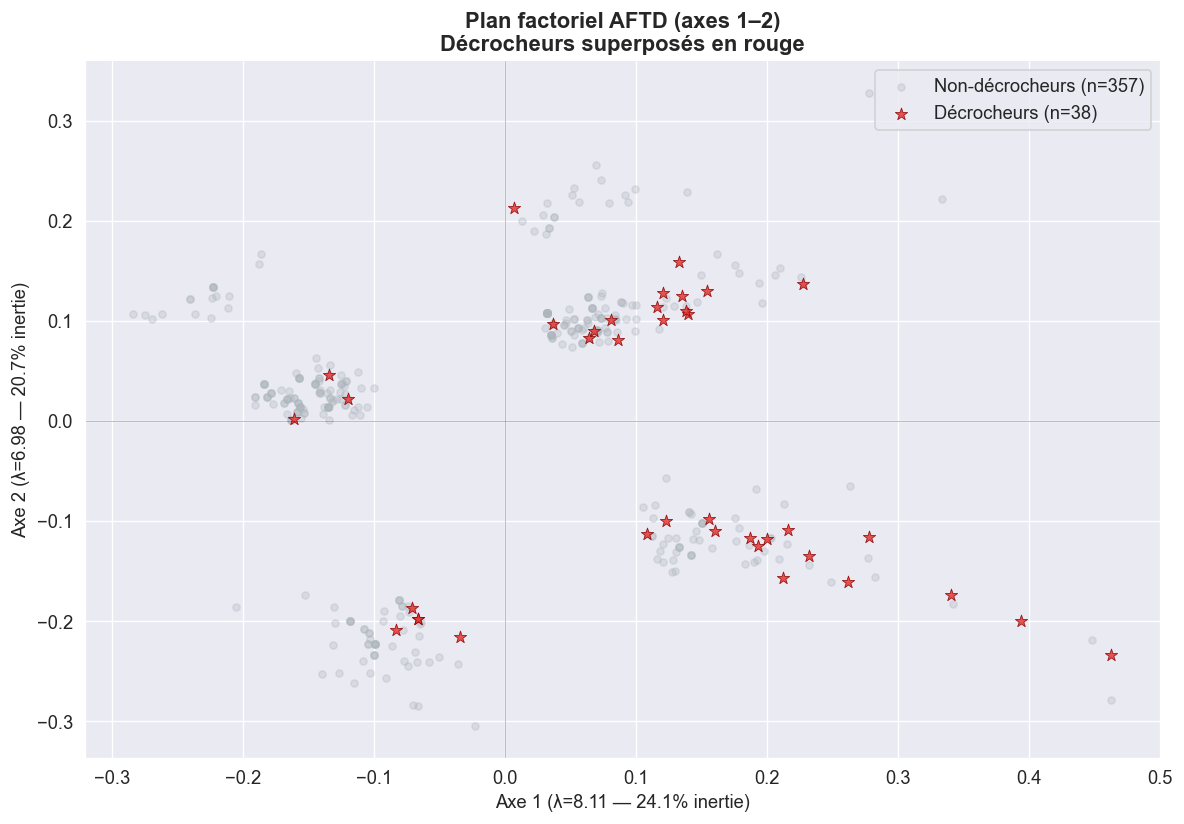

In [6]:
# Plan factoriel 1-2 avec décrocheurs superposés
dec_mask = mat['decrocheur'].values == 1

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(C2[~dec_mask,0], C2[~dec_mask,1], s=18, alpha=0.3,
           color='#adb5bd', label='Non-décrocheurs (n=357)', zorder=1)
ax.scatter(C2[dec_mask,0],  C2[dec_mask,1],  s=60, alpha=0.85,
           color=ROUGE, marker='*', edgecolors='darkred', lw=0.5,
           label='Décrocheurs (n=38)', zorder=2)
ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.axvline(0, color='k', lw=0.5, alpha=0.3)
ax.set_xlabel(f'Axe 1 (λ={lam[0]:.2f} — {pct[0]:.1f}% inertie)')
ax.set_ylabel(f'Axe 2 (λ={lam[1]:.2f} — {pct[1]:.1f}% inertie)')
ax.set_title('Plan factoriel AFTD (axes 1–2)\nDécrocheurs superposés en rouge',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Classification Ascendante Hiérarchique — Méthode de Ward

### 5.1 Rappel théorique (cours Ch. 7, §5.5)

Ward fusionne à chaque étape les deux classes minimisant l'augmentation de l'inertie intra-classe :
$$D(A, B) = \frac{n_A \cdot n_B}{n_A + n_B} \cdot d^2(g_A, g_B)$$

Ward est appliqué ici sur les **coordonnées factorielles** (euclidiennes par construction).
Le cours (§5.7) recommande d'utiliser conjointement une méthode de réduction de dimension
avant la classification, ici l'AFTD.

Le choix de K repose sur **deux critères conjoints** :
1. La **méthode du coude sur les sauts d'inertie** (cours §4.3) — saut le plus grand
   à la coupure K→K-1
2. L'**interprétabilité des profils** — un K trop grand produit des clusters non
   distinguables sur les variables de sélection

In [7]:
# Ward sur les coordonnées factorielles (euclidiennes par construction)
Z_ward = linkage(C2, method='ward')

# Sauts d'inertie pour choisir K (cours §4.3)
fusion_dists = Z_ward[-15:, 2][::-1]
sauts_all = [fusion_dists[i] - fusion_dists[i+1]
             for i in range(len(fusion_dists)-1)]

print("Sauts d'inertie (distances de fusion Ward)")
print(f"{'K':>4} {'Dist. fusion':>14} {'Saut →K-1':>12}")
print("-" * 34)
for i in range(len(sauts_all)):
    saut = sauts_all[i]
    marq = " ← saut maximal" if saut == max(sauts_all) else ""
    print(f"{i+2:>4} {fusion_dists[i]:>14.4f} {saut:>12.4f}{marq}")

Sauts d'inertie (distances de fusion Ward)
   K   Dist. fusion    Saut →K-1
----------------------------------
   2         3.5529       0.6469
   3         2.9059       0.5304
   4         2.3755       1.5122 ← saut maximal
   5         0.8634       0.1039
   6         0.7595       0.0437
   7         0.7157       0.0504
   8         0.6653       0.1985
   9         0.4669       0.0672
  10         0.3997       0.1348
  11         0.2649       0.0130
  12         0.2518       0.0110
  13         0.2408       0.0229
  14         0.2179       0.0048
  15         0.2131       0.0030


### 5.2 Lecture des sauts d'inertie et choix de K

Le tableau ci-dessus révèle un signal clair :

- **Le saut maximal est à K=4** (1,51) — passer de 4 à 3 clusters coûte nettement
  plus que toutes les autres fusions. C'est le signal le plus fort pour arrêter la
  partition à K=4.
- Les sauts à K=2 (0,65) et K=3 (0,53) sont du même ordre et nettement inférieurs,
  ce qui écarte ces solutions.
- Au-delà de K=4, les sauts chutent brutalement (< 0,20) — les fusions suivantes
  regroupent des clusters proches sans gain structurel.

Le coude sur les sauts d'inertie pointe donc sans ambiguïté vers **K=4**. Le
dendrogramme et l'interprétabilité des profils viendront confirmer ce choix.

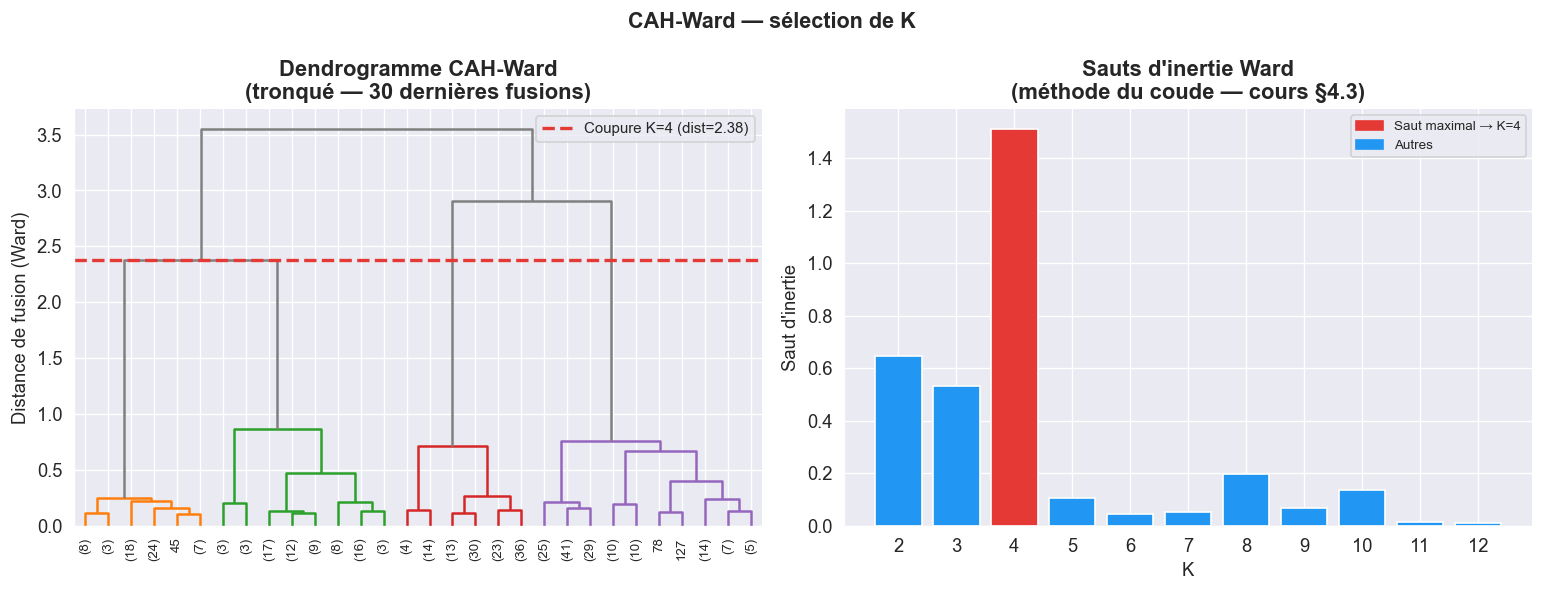

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Dendrogramme tronqué ──
ax1 = axes[0]
threshold_4 = Z_ward[-(4-1), 2]
dendrogram(Z_ward, ax=ax1, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=threshold_4,
           above_threshold_color='gray')
ax1.axhline(threshold_4, color=ROUGE, lw=2, ls='--',
            label=f'Coupure K=4 (dist={threshold_4:.2f})')
ax1.set_title('Dendrogramme CAH-Ward\n(tronqué — 30 dernières fusions)', fontweight='bold')
ax1.set_ylabel('Distance de fusion (Ward)')
ax1.legend(fontsize=9)

# ── Sauts d'inertie ──
ax2 = axes[1]
fds   = Z_ward[-12:, 2][::-1]
sauts = [fds[i]-fds[i+1] for i in range(len(fds)-1)]
Ks_s  = range(2, len(sauts)+2)
colors_bar = [ROUGE if s == max(sauts) else BLEU for s in sauts]
ax2.bar(Ks_s, sauts, color=colors_bar, edgecolor='white')
ax2.set_xlabel('K')
ax2.set_ylabel("Saut d'inertie")
ax2.set_title("Sauts d'inertie Ward\n(méthode du coude — cours §4.3)", fontweight='bold')
ax2.set_xticks(list(Ks_s))
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color=ROUGE, label='Saut maximal → K=4'),
                    Patch(color=BLEU,  label='Autres')], fontsize=8)

plt.suptitle("CAH-Ward — sélection de K", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 Décision : K = 4

On retient **K=4** pour deux raisons convergentes :

1. **Sauts d'inertie :** le saut maximal est sans ambiguïté à K=4 (1,51), nettement
   supérieur à tous les autres sauts (≤ 0,65). C'est le signal le plus direct de la
   méthode du coude.
2. **Dendrogramme :** la coupure à K=4 isole quatre branches clairement séparées.
   Descendre à K=3 ou K=2 fusionnerait des groupes visiblement distincts ; monter à
   K=5 scinderait un cluster homogène sans gain structurel visible.

Ces deux critères convergent — K=4 est retenu sans ambiguïté.

In [9]:
K = 4
labels_cah = fcluster(Z_ward, K, criterion='maxclust') - 1   # 0-indexé

print(f"Partition CAH-Ward en K={K} classes :")
print(f"{'Cluster':>9} {'n':>6} {'n décrocheurs':>15} {'Taux décrochage':>18}")
print("-" * 52)
for k in range(K):
    mask = labels_cah == k
    n_k  = mask.sum()
    n_d  = ((labels_cah == k) & (mat['decrocheur'] == 1)).sum()
    print(f" C{k}  {n_k:>6}  {n_d:>15}  {100*n_d/n_k:>17.1f}%")

Partition CAH-Ward en K=4 classes :
  Cluster      n   n décrocheurs    Taux décrochage
----------------------------------------------------
 C0      61                5                8.2%
 C1      71               15               21.1%
 C2     120                3                2.5%
 C3     143               15               10.5%


---
## 6. Méthode des K-means (centres mobiles)

### 6.1 Rappel théorique (cours Ch. 7, §6.1)

La méthode des centres mobiles minimise $I_W(P)$ par optimisation alternée : affectation au centre le plus proche, puis mise à jour des centres de gravité. Le cours note que l'algorithme est **sensible à l'initialisation** (risque d'optimum local). On utilise `k-means++` — initialisation améliorée cohérente avec cette précaution du cours.

K-means est appliqué sur les **mêmes coordonnées factorielles** que la CAH pour permettre la comparaison ARI à iso-représentation.

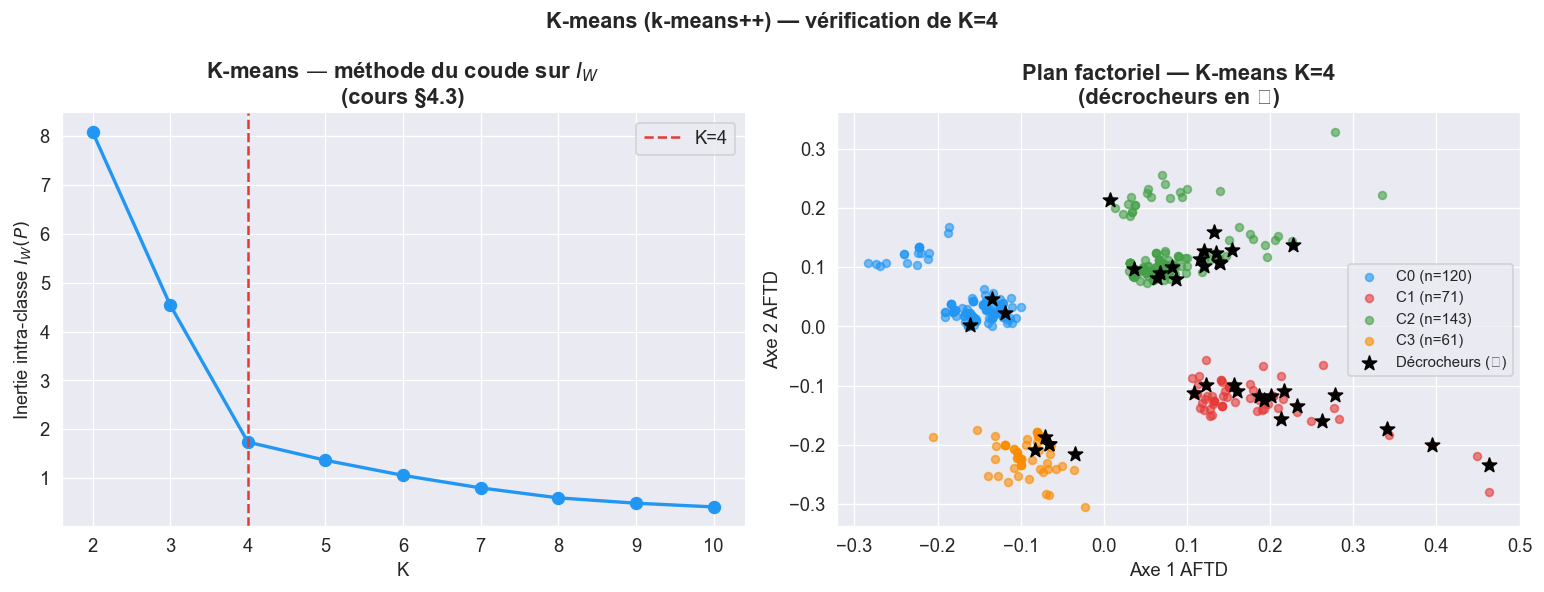

Partition K-means K=4 :
  C0 : n=120, décrocheurs=3 (2.5%)
  C1 : n=71, décrocheurs=15 (21.1%)
  C2 : n=143, décrocheurs=15 (10.5%)
  C3 : n=61, décrocheurs=5 (8.2%)


In [10]:
# Méthode du coude sur I_W(P) pour confirmer K=4
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    km.fit(C2)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Courbe d'inertie intra-classe
ax = axes[0]
Ks_ = list(range(2, 11))
ax.plot(Ks_, inertias, 'o-', color=BLEU, lw=2, ms=7)
ax.axvline(4, color=ROUGE, lw=1.5, ls='--', label='K=4')
ax.set_xlabel('K')
ax.set_ylabel('Inertie intra-classe $I_W(P)$')
ax.set_title('K-means — méthode du coude sur $I_W$\n(cours §4.3)', fontweight='bold')
ax.set_xticks(Ks_)
ax.legend()

# K-means final K=4
km_final  = KMeans(n_clusters=4, init='k-means++', n_init=50, random_state=42)
labels_km = km_final.fit_predict(C2)

# Plan factoriel coloré
ax2 = axes[1]
for k in range(4):
    mask = labels_km == k
    ax2.scatter(C2[mask,0], C2[mask,1], s=22, alpha=0.6,
                color=PAL[k], label=f'C{k} (n={mask.sum()})')
ax2.scatter(C2[dec_mask,0], C2[dec_mask,1], s=80, marker='*',
            color='black', zorder=3, label='Décrocheurs (★)')
ax2.set_xlabel('Axe 1 AFTD')
ax2.set_ylabel('Axe 2 AFTD')
ax2.set_title('Plan factoriel — K-means K=4\n(décrocheurs en ★)', fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('K-means (k-means++) — vérification de K=4', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("Partition K-means K=4 :")
for k in range(4):
    n_k = (labels_km==k).sum()
    n_d = ((labels_km==k) & (mat['decrocheur']==1)).sum()
    print(f"  C{k} : n={n_k}, décrocheurs={n_d} ({100*n_d/n_k:.1f}%)")

La courbe $I_W(K)$ présente un **coude à K=4** — le gain marginal chute nettement
au-delà. K-means confirme ainsi indépendamment le choix de la CAH-Ward.

---
## 7. Comparaison des partitions — Indice de Rand Ajusté

### 7.1 Rappel théorique (cours Ch. 7, §7 — Définition 16)

L'ARI compare deux partitions en corrigeant l'espérance de l'indice de Rand sous l'hypothèse d'indépendance. ARI=1 si P=Q ; ARI≈0 si indépendant. Un ARI élevé entre deux méthodes de **natures fondamentalement différentes** (CAH hiérarchique vs K-means itératif) est un **argument de robustesse fort** : la structure trouvée ne dépend pas de l'algorithme utilisé.

In [11]:
ari = adjusted_rand_score(labels_cah, labels_km)

conf = pd.crosstab(
    pd.Series(labels_cah, name='CAH-Ward'),
    pd.Series(labels_km,  name='K-means'),
    rownames=['CAH-Ward'],
    colnames=['K-means'],
    margins=True,
    margins_name='Total'
)
# Renommer les index pour plus de clarté
conf.index   = [f'C{i}' if i != 'Total' else 'Total' for i in conf.index]
conf.columns = [f'C{j}' if j != 'Total' else 'Total' for j in conf.columns]

print(f"ARI (CAH-Ward vs K-means) = {ari:.4f}")
print()
print("Matrice de contingence :")
print(conf.to_string())
print()
if ari > 0.99:
    print("→ ARI = 1,000 : les deux méthodes produisent exactement la même partition.")
    print("  La structure K=4 est robuste — indépendante de l'algorithme utilisé.")
else:
    print(f"→ ARI = {ari:.3f} : convergence {'forte' if ari > 0.80 else 'modérée'} entre les deux méthodes.")

ARI (CAH-Ward vs K-means) = 1.0000

Matrice de contingence :
        C0  C1   C2  C3  Total
C0       0   0    0  61     61
C1       0  71    0   0     71
C2     120   0    0   0    120
C3       0   0  143   0    143
Total  120  71  143  61    395

→ ARI = 1,000 : les deux méthodes produisent exactement la même partition.
  La structure K=4 est robuste — indépendante de l'algorithme utilisé.


## 8. Caractérisation descriptive des 4 profils

Les clusters sont caractérisés sur les **8 variables ayant servi au clustering**
(section 2). Le taux de décrochage est affiché à titre indicatif dans les titres
des graphes — son interprétation formelle est réservée au notebook 3 qui établira
statistiquement le lien entre profils et décrochage.

Profil moyen par cluster (K-means, K=4)
           n  failures  Medu    age  Walc  higher  paid  schoolsup  romantic
cluster                                                                     
0        120      0.16  2.88  16.48  2.38    1.00   1.0       0.15       0.0
1         71      0.61  2.61  17.01  2.18    0.86   0.0       0.11       1.0
2        143      0.39  2.58  16.60  2.24    0.94   0.0       0.15       0.0
3         61      0.23  3.05  16.97  2.38    0.98   1.0       0.07       1.0


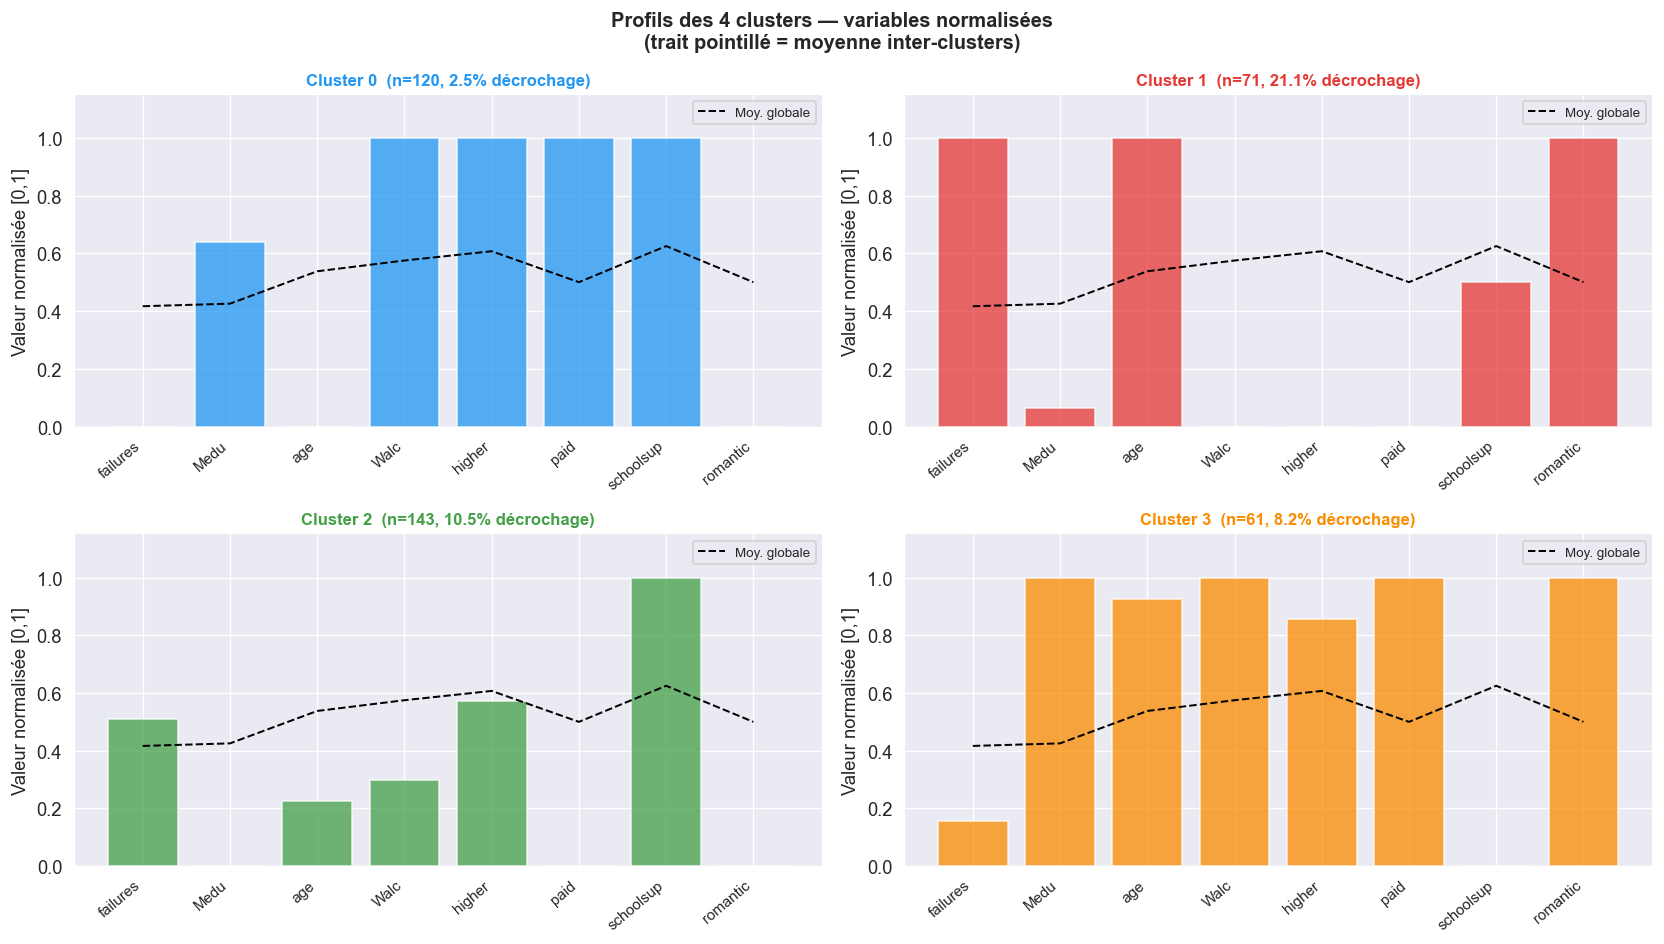

In [16]:
mat['cluster'] = labels_km

# Profil moyen par cluster
profil = mat.groupby('cluster')[VARS_NUM].mean().round(2)
for v in VARS_CAT:
    profil[v] = (mat.groupby('cluster')[v]
                    .apply(lambda x: (x == 'yes').mean())).round(2)
profil['n'] = mat.groupby('cluster')['decrocheur'].count()
profil['taux_dec'] = (mat.groupby('cluster')['decrocheur'].mean() * 100).round(1)

cols_show = ['n', 'failures', 'Medu', 'age', 'Walc', 'higher', 'paid', 'schoolsup', 'romantic']
print("Profil moyen par cluster (K-means, K=4)")
print(profil[cols_show].to_string())

vars_show  = VARS_NUM + VARS_CAT
profil_num = profil[vars_show].copy()
maxv = profil_num.max().values
minv = profil_num.min().values

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for k, ax in enumerate(axes):
    vals_k = profil_num.loc[k].values.astype(float)
    glob   = profil_num.mean().values
    vals_n = (vals_k - minv) / (maxv - minv + 1e-9)
    glob_n = (glob   - minv) / (maxv - minv + 1e-9)
    x = np.arange(len(vars_show))
    ax.bar(x, vals_n, color=PAL[k], alpha=0.75, edgecolor='white')
    ax.plot(x, glob_n, 'k--', lw=1.2, label='Moy. globale')
    ax.set_xticks(x)
    ax.set_xticklabels(vars_show, rotation=40, ha='right', fontsize=9)
    ax.set_ylim(0, 1.15)
    n_k   = int(profil.loc[k, 'n'])
    taux  = profil.loc[k, 'taux_dec']
    ax.set_title(f'Cluster {k}  (n={n_k}, {taux:.1f}% décrochage)',
                 fontsize=10, fontweight='bold', color=PAL[k])
    ax.set_ylabel('Valeur normalisée [0,1]')
    ax.legend(fontsize=8)

plt.suptitle('Profils des 4 clusters — variables normalisées\n'
             '(trait pointillé = moyenne inter-clusters)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

**Lecture des profils**

Le tableau des moyennes et le graphique normalisé permettent de caractériser les 4 profils :

- **C0 (n=120, 2,5% décrochage)** : failures très faibles (0,16), Medu élevée (2,88),
  aspiration aux études supérieures quasi universelle (100%), cours particuliers payants
  (100%), pas de soutien scolaire institutionnel. Profil de départ favorable.

- **C1 (n=71, 21,1% décrochage)** : failures les plus élevés (0,61), Medu la plus faible
  (2,61), aucun cours particulier payant (0%), faible aspiration aux études supérieures
  (86%), relation amoureuse très fréquente (100%). Profil cumulant le plus de facteurs
  de vulnérabilité.

- **C2 (n=143, 10,5% décrochage)** : failures modérés (0,39), Medu faible (2,58),
  aucun cours particulier (0%), aspiration aux études supérieures moyenne (94%).
  Profil intermédiaire sans soutien externe.

- **C3 (n=61, 8,2% décrochage)** : failures faibles (0,23), Medu la plus élevée (3,05),
  aspiration aux études supérieures quasi universelle (98%), cours particuliers payants
  (100%). Profil favorisé sur le plan familial.

**Observation sur Walc :** la consommation d'alcool le week-end est plus élevée dans
les clusters à faible taux de décrochage (C0, C3) que dans C1 qui présente le taux
le plus élevé. Ce signal contre-intuitif — et à interpréter avec prudence — suggère
que `Walc` capte davantage un effet de contexte social (milieu favorisé, vie sociale
active) qu'un facteur de risque direct. C'est une limite de l'interprétation causale
de cette variable.

> **Important :** les taux de décrochage sont présentés à titre *indicatif*. Le lien
> statistique entre cluster et décrochage sera établi formellement en notebook 3
> (Phase A : test χ²).

---
## 9. Synthèse et articulation avec le notebook 3

### 9.1 Résultats clés

### 9.1 Résultats clés

| Indicateur | Valeur |
|------------|--------|
| AFTD — inertie cumulée (2 axes) | 44,9 % |
| Shepard r (dim=2) | 0,842 |
| Shepard RMSE relatif | 9,8 % de d_max |
| Val. propres négatives | 375 / 395 |
| K retenu (CAH-Ward + K-means) | 4 |
| ARI (CAH-Ward vs K-means) | 1,000 |

### 9.2 Bilan et limites de l'étape 1

**Acquis :** quatre profils structurés émergent des seules variables
socio-comportementales disponibles en début d'année. La structure est robuste
(ARI = 1,000 entre CAH-Ward et K-means). Le cluster C1 — failures élevés, Medu
faible, sans soutien externe — concentre 21,1% de décrochage contre 9,6% en moyenne.

**Limites :** un taux élevé dans un cluster ne suffit pas à conclure.
Il faut vérifier que l'association entre profil et décrochage est statistiquement
significative, et que les profils permettent de prédire individuellement le décrochage.

Le notebook 3 enchaîne avec :
- **Phase A :** test χ² — les clusters séparent-ils significativement les décrocheurs ?
- **Phase B :** panel de classifieurs supervisés avec estimation robuste du risque
  (holdout, validation croisée, bootstrap .632)
- **Phase C :** triangulation et conclusion sur la problématique
